# Cap. 03 — Introducción a los Algoritmos Cuánticos
## Listing 3-10: Desigualdad de Bell — Juego CHSH (Qiskit)

**Referencia:** Pattanayak, *Quantum Machine Learning with Python*, Capítulo 3, Listing 3-10.  
Implementación equivalente en Qiskit del notebook Cirq `08_bell_inequality.ipynb`.

---

### El juego de cooperación

Alice y Bob juegan contra un árbitro siguiendo estas reglas:

1. El árbitro envía un bit $x_1 \in \{0,1\}$ a Alice y un bit $x_2 \in \{0,1\}$ a Bob de forma **independiente y aleatoria**.
2. Alice responde con un bit $a(x_1)$ y Bob con un bit $b(x_2)$, **sin poder comunicarse entre sí**.
3. **Ganan** si: $a(x_1) \oplus b(x_2) = x_1 \cdot x_2$

La regla en palabras directas: **casi siempre deben responder lo mismo, excepto cuando los dos reciben 1**:

| $x_1$ | $x_2$ | Condición de victoria | Intuición |
|:---:|:---:|:---:|---|
| 0 | 0 | $a = b$ | mismos bits |
| 0 | 1 | $a = b$ | mismos bits |
| 1 | 0 | $a = b$ | mismos bits |
| 1 | 1 | $a \neq b$ | bits distintos |

---

### Por qué el 75% es el techo clásico

Cualquier estrategia clásica se puede escribir como dos funciones fijas: $a(x_1)$ y $b(x_2)$. Solo hay 4 combinaciones posibles:

| Estrategia | (0,0) | (0,1) | (1,0) | (1,1) | Victorias |
|---|:---:|:---:|:---:|:---:|:---:|
| $a=0, b=0$ | ✓ | ✓ | ✓ | ✗ | 3/4 |
| $a=1, b=1$ | ✓ | ✓ | ✓ | ✗ | 3/4 |
| $a=0, b=1$ | ✗ | ✗ | ✗ | ✓ | 1/4 |
| $a=1, b=0$ | ✗ | ✗ | ✗ | ✓ | 1/4 |

Es un **límite duro** — ninguna estrategia clásica, ni aleatoria ni determinista, puede superarlo.

---

### Ventaja cuántica: ~85%

Compartiendo el estado de Bell $\frac{1}{\sqrt{2}}(\vert 00\rangle + \vert 11\rangle)$, Alice y Bob eligen el ángulo de medición según el bit recibido:

| Jugador | Si recibe | Mide en la base |
|---|:---:|---|
| Alice | $x_1 = 0$ | base estándar ($0°$) |
| Alice | $x_1 = 1$ | base rotada $45°$ |
| Bob   | $x_2 = 0$ | base rotada $22.5°$ |
| Bob   | $x_2 = 1$ | base rotada $-22.5°$ |

$$P(\text{victoria}) = \cos^2\!\left(\frac{\pi}{8}\right) \approx 85.4\%$$

Que ninguna estrategia clásica pueda superar el 75% se llama **desigualdad de Bell**. Aspect, Clauser y Zeilinger recibieron el **Nobel de Física 2022** por verificarlo experimentalmente.

---

### Qubits del circuito

| Qubit | Rol |
|:---:|---|
| Q0 | Qubit de Alice (mitad del par de Bell) |
| Q1 | Bit del árbitro para Alice ($r_A = x_1$) |
| Q2 | Qubit de Bob (mitad del par de Bell) |
| Q3 | Bit del árbitro para Bob ($r_B = x_2$) |

### Diferencias de API respecto al libro (Qiskit 1.0+)

| Libro (API antigua) | Este notebook (Qiskit ≥1.0) |
|---|---|
| `from qiskit import execute, Aer` | `from qiskit_aer import AerSimulator` |
| `cirq.X(q)**(-0.25)` | `XGate().power(-0.25)` |
| `cirq.CNOT(c, t)**0.5` | `CXGate().power(0.5)` |

### Circuito

In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import XGate, CXGate
from qiskit_aer import AerSimulator


def bell_inequality_test_circuit():
    """
    Construye el circuito del juego CHSH para probar la desigualdad de Bell.

    Q0: qubit de Alice   Q1: bit árbitro → Alice (r_A)
    Q2: qubit de Bob     Q3: bit árbitro → Bob   (r_B)
    c[0]=A, c[1]=r_A, c[2]=B, c[3]=r_B
    """
    circuit = QuantumCircuit(4, 4)

    # Paso 1: crear el par de Bell |Φ+⟩ entre Alice (Q0) y Bob (Q2)
    # H(Q0) → superposición, CX(Q0→Q2) → entrelazamiento
    circuit.h(0)
    circuit.cx(0, 2)

    # Paso 2: Alice aplica X^(-0.25) en su qubit
    # Rota la base de medición de Alice en -π/4 respecto a la base estándar
    circuit.append(XGate().power(-0.25), [0])

    # Paso 3: el árbitro genera bits aleatorios para Alice y Bob con Hadamard
    # H sobre |0⟩ da superposición uniforme → al medir: 0 o 1 con prob. 0.5
    circuit.h(1)  # r_A: bit aleatorio para Alice
    circuit.h(3)  # r_B: bit aleatorio para Bob

    # Paso 4: rotación condicional en función del bit del árbitro
    # CX^0.5 (sqrt(CX)): si el bit del árbitro es 1, rota el qubit del jugador
    # Alice: si r_A=1 → rota Q0 en π/4 adicional
    circuit.append(CXGate().power(0.5), [1, 0])
    # Bob: si r_B=1 → cambia de base π/8 → -π/8
    circuit.append(CXGate().power(0.5), [3, 2])

    # Paso 5: medir cada qubit en su propio bit clásico para análisis separado
    circuit.measure(0, 0)  # A   → c[0]
    circuit.measure(1, 1)  # r_A → c[1]
    circuit.measure(2, 2)  # B   → c[2]
    circuit.measure(3, 3)  # r_B → c[3]

    return circuit

In [2]:
circuit = bell_inequality_test_circuit()
print(circuit.draw(output='text'))

     ┌───┐     ┌─────────┐┌─────────┐   ┌─┐   
q_0: ┤ H ├──■──┤ x^-0.25 ├┤1        ├───┤M├───
     ├───┤  │  └─────────┘│  cx^0.5 │   └╥┘┌─┐
q_1: ┤ H ├──┼─────────────┤0        ├────╫─┤M├
     └───┘┌─┴─┐┌─────────┐└───┬─┬───┘    ║ └╥┘
q_2: ─────┤ X ├┤1        ├────┤M├────────╫──╫─
     ┌───┐└───┘│  cx^0.5 │    └╥┘    ┌─┐ ║  ║ 
q_3: ┤ H ├─────┤0        ├─────╫─────┤M├─╫──╫─
     └───┘     └─────────┘     ║     └╥┘ ║  ║ 
c: 4/══════════════════════════╩══════╩══╩══╩═
                               2      3  0  1 


### Visualización del circuito

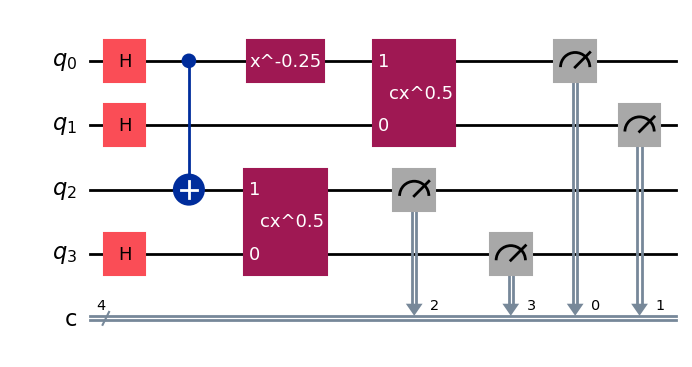

In [3]:
circuit.draw('mpl')

### Simulación y tasa de victoria

**Condición de victoria:** $(A + B) \bmod 2 = r_A \mathbin{\&} r_B$

> **Nota sobre el orden de bits en Qiskit:** el resultado se devuelve como `c[3]c[2]c[1]c[0]` (MSB primero).  
> Una cadena `'1010'` significa $r_B=1, B=0, r_A=1, A=0$.

In [4]:
ITERS = 1000

simulator = AerSimulator()
counts = simulator.run(transpile(circuit, simulator), shots=ITERS).result().get_counts()

# Analizar resultados por combinación de bits del árbitro
wins_total = 0
scenario_data = {(ra, rb): {'wins': 0, 'total': 0} for ra in (0, 1) for rb in (0, 1)}

for bitstring, count in counts.items():
    # Orden Qiskit: c[3]c[2]c[1]c[0] → r_B, B, r_A, A
    r_B = int(bitstring[0])
    B   = int(bitstring[1])
    r_A = int(bitstring[2])
    A   = int(bitstring[3])

    win = (A + B) % 2 == (r_A & r_B)
    scenario_data[(r_A, r_B)]['total'] += count
    if win:
        scenario_data[(r_A, r_B)]['wins'] += count
        wins_total += count

tasa_victoria  = 100 * wins_total / ITERS
limite_clasico  = 75.0
limite_cuantico = 100 * np.cos(np.pi / 8) ** 2

print(f"Tasa de victoria cuántica:    {tasa_victoria:.1f}%")
print(f"Límite clásico (máximo):       {limite_clasico:.1f}%")
print(f"Límite cuántico teórico:       {limite_cuantico:.1f}%")
print(f"Violación de la desigualdad:   {'SÍ' if tasa_victoria > limite_clasico else 'NO'}")

Tasa de victoria cuántica:    86.2%
Límite clásico (máximo):       75.0%
Límite cuántico teórico:       85.4%
Violación de la desigualdad:   SÍ


### Tasa de victoria por combinación de bits del árbitro

In [5]:
import matplotlib.pyplot as plt

escenarios = [(0, 0), (0, 1), (1, 0), (1, 1)]
tasas = []
etiquetas = []

for ra, rb in escenarios:
    d = scenario_data[(ra, rb)]
    tasa = 100 * d['wins'] / d['total'] if d['total'] > 0 else 0.0
    tasas.append(tasa)
    etiquetas.append(f'$r_A={ra}, r_B={rb}$')
    print(f"r_A={ra}, r_B={rb}: {d['total']:4d} casos → victoria {tasa:.1f}%")

print(f"\nVictoria global: {tasa_victoria:.1f}%")

r_A=0, r_B=0:  247 casos → victoria 85.0%
r_A=0, r_B=1:  218 casos → victoria 87.2%
r_A=1, r_B=0:  267 casos → victoria 85.0%
r_A=1, r_B=1:  268 casos → victoria 87.7%

Victoria global: 86.2%


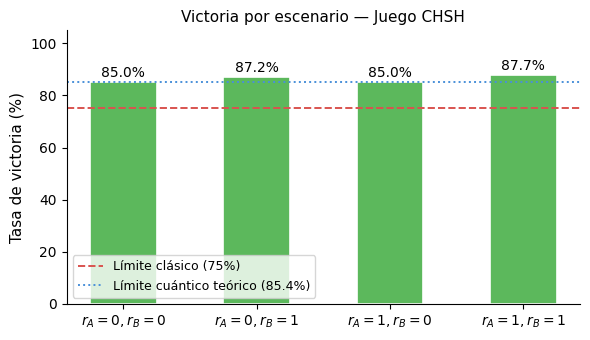

In [6]:
colores = ['#5cb85c' if t > limite_clasico else '#d9534f' for t in tasas]

fig, ax = plt.subplots(figsize=(6, 3.5))
barras = ax.bar(etiquetas, tasas, color=colores, edgecolor='white', linewidth=1.2, width=0.5)

ax.axhline(limite_clasico, color='#d9534f', linestyle='--', linewidth=1.4,
           label=f'Límite clásico ({limite_clasico:.0f}%)')
ax.axhline(limite_cuantico, color='#4a90d9', linestyle=':', linewidth=1.4,
           label=f'Límite cuántico teórico ({limite_cuantico:.1f}%)')

for barra, t in zip(barras, tasas):
    ax.text(barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.8,
            f'{t:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Tasa de victoria (%)', fontsize=11)
ax.set_title('Victoria por escenario — Juego CHSH', fontsize=11)
ax.set_ylim(0, 105)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Interpretación:** las barras verdes superan el límite clásico del 75% en todos los escenarios — evidencia de la **violación de la desigualdad de Bell**.

Si Eve interceptara los qubits, el entrelazamiento se rompería y la tasa de victoria caería por debajo del 75%, delatando la escucha. Este es el principio detrás de la **criptografía cuántica (QKD)**.